<a href="https://www.kaggle.com/code/allasamoilenko/fruit-classification?scriptVersionId=229279509" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import torchvision.utils as vutils
device = 'cuda' if torch.cuda.is_available() else 'cpu'

root_dir = '/kaggle/input/fruit-recognition/train/train'
test_path = '/kaggle/input/fruit-recognition/test'

In [2]:
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),  
    transforms.RandomHorizontalFlip(p=0.5),  
    transforms.RandomRotation(degrees=15), 
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  
    transforms.ToTensor(),  
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  
])

test_transforms = transforms.Compose([
    transforms.Resize((256, 256)), 
    transforms.ToTensor(), 
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) 
])

In [3]:
train_dataset = datasets.ImageFolder(root_dir, transform=train_transforms)

In [4]:
train_ratio = 0.8
train_size = int(train_ratio * len(train_dataset))
val_size = len(train_dataset) - train_size
train_data, val_data = random_split(train_dataset, [train_size, val_size])

In [5]:
test_dataset = datasets.ImageFolder(test_path, transform=test_transforms)

In [6]:
batch_size = 32
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [7]:
def show_images(images, labels, classes):
    plt.figure(figsize=(10, 10))
    plt.axis("off")
    plt.title("Training Images")
    grid = vutils.make_grid(images, nrow=8).permute(1, 2, 0) 
    plt.imshow(grid)
    plt.show()

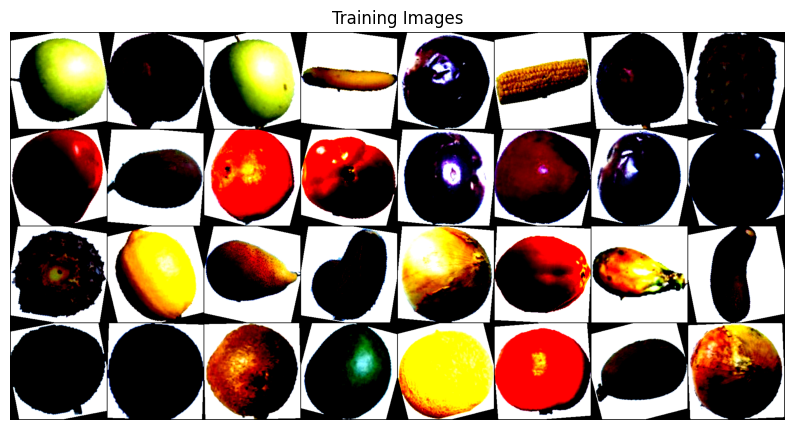

In [8]:
images, labels = next(iter(train_loader))
show_images(images, labels, train_dataset.classes)